# 3.2 真实世界降维打击实战：波士顿房价预测
我们将把你刚才手写的底层公式，直接砸向真实世界的房价数据，看看这几行破代码是如何榨取商业价值的。

## 1. 从真实世界采矿 (获取数据)

In [1]:
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt

# 强制内嵌渲染
%matplotlib inline

# 从网上直接拉取开源的真实波士顿房价数据集
data_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
raw_data = pd.read_csv(data_url)
print("原始数据长这样：\n", raw_data.head())

原始数据长这样：
       crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


## 2. 剥离特征与标签，并执行物理降维 (标准化)
这就是真实世界的毒打：你不经过标准化，直接把原始数据喂进去，底层的梯度会瞬间爆炸。

In [2]:
# 提取特征 (X) 和 真理标签 (y)
# 我们提取 RM(房间数) 和 LSTAT(低收入群体比例) 作为预测房价的两个物理指标
features = raw_data[['rm', 'lstat']].to_numpy(dtype=float)
labels = raw_data['medv'].to_numpy(dtype=float)

# 转换为 PyTorch 的张量
features = torch.tensor(features, dtype=torch.float32)
labels = torch.tensor(labels, dtype=torch.float32)

# 【真实世界的毒打：标准化 (Z-score)】
# 在玩具数据里我们不需要做这步，但在现实世界，RM 的数值在 6 左右，而 LSTAT 可能高达 30。
# 如果不强制把它们拉平到同一数量级（均值为 0，标准差为 1），优化器的梯度会瞬间原地爆炸！
features = (features - features.mean(dim=0)) / features.std(dim=0)

# 把一维的真实标签 (506,) 强行重塑为二维列向量 (506, 1) 防御广播爆炸
labels = labels.reshape((-1, 1))

print("清洗后的特征形状:", features.shape)
print("清洗后的标签形状:", labels.shape)

清洗后的特征形状: torch.Size([506, 2])
清洗后的标签形状: torch.Size([506, 1])


## 3. 复用你刚手写的标准 5 步引擎
完全原封不动地照搬 D2L 的代码。

In [3]:
# 1. 小批量传送带 (完全复原 D2L 源码)
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices) # 打乱顺序，模拟真实世界的随机性
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# 2. 压模机 (完全复原 D2L 源码)
def linreg(X, w, b): 
    return torch.matmul(X, w) + b

# 3. 质检计损器 (完全复原 D2L 源码)
def squared_loss(y_hat, y): 
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# 4. 拧旋钮机械臂 (完全复原 D2L 源码)
def sgd(params, lr, batch_size): 
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 4. 初始化模型参数，并开始训练！

In [4]:
# 初始化 (特征现在是2个，所以w是 2x1 的列向量)
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# 训练超参数
lr = 0.03
num_epochs = 15
batch_size = 10
net = linreg
loss = squared_loss

loss_history = [] # 记录损失变化用于画图

print("=== 开始训练 ===")
for epoch in range(num_epochs):
    # 步骤 1：传送带送数据
    for X, y in data_iter(batch_size, features, labels):
        # 步骤 2 & 3：正向压模并计算误差
        l = loss(net(X, w, b), y)
        
        # 步骤 4：反向拉警报 (求梯度)
        l.sum().backward()
        
        # 步骤 5：暴力微调并清零
        sgd([w, b], lr, batch_size)
        
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        epoch_loss = train_l.mean().item()
        loss_history.append(epoch_loss)
        print(f'Epoch {epoch + 1}, 均方误差 (Loss): {epoch_loss:.5f}')

=== 开始训练 ===
Epoch 1, 均方误差 (Loss): 26.76879
Epoch 2, 均方误差 (Loss): 15.71180
Epoch 3, 均方误差 (Loss): 15.25793
Epoch 4, 均方误差 (Loss): 15.26653
Epoch 5, 均方误差 (Loss): 15.32665
Epoch 6, 均方误差 (Loss): 15.27786
Epoch 7, 均方误差 (Loss): 15.26036
Epoch 8, 均方误差 (Loss): 15.25931
Epoch 9, 均方误差 (Loss): 15.25962
Epoch 10, 均方误差 (Loss): 15.30703
Epoch 11, 均方误差 (Loss): 15.26858
Epoch 12, 均方误差 (Loss): 15.27639
Epoch 13, 均方误差 (Loss): 15.35201
Epoch 14, 均方误差 (Loss): 15.29593
Epoch 15, 均方误差 (Loss): 15.25891


## 5. 将 Loss 的物理下降过程可视化

c:\Users\34331\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\34331\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\34331\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\34331\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\34331\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing f

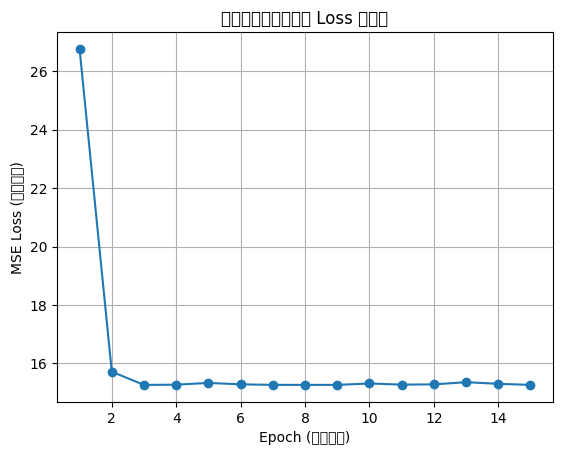

模型认为房间数(RM)的权重是: 3.650052070617676
模型认为低收入人群比例(LSTAT)的权重是: -4.567477226257324


In [5]:
# 把张量剥离出来，扔给 matplotlib 画图
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.xlabel('Epoch (训练轮次)')
plt.ylabel('MSE Loss (均方误差)')
plt.title('真实世界房价预测的 Loss 收敛图')
plt.grid(True)
plt.show()

# 偷看一眼模型学到的真理参数
print("模型认为房间数(RM)的权重是:", w[0].item())
print("模型认为低收入人群比例(LSTAT)的权重是:", w[1].item())